In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
%matplotlib inline

In [4]:
sns.set_style("whitegrid")

In [5]:
df = pd.read_excel("Coffee Shop Sales.xlsx")

In [6]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [7]:
print( df.shape)

(149116, 11)


In [8]:
print(df.columns)


Index(['transaction_id', 'transaction_date', 'transaction_time',
       'transaction_qty', 'store_id', 'store_location', 'product_id',
       'unit_price', 'product_category', 'product_type', 'product_detail'],
      dtype='object')


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 non-null  int64         
 7   unit_price        149116 non-null  float64       
 8   product_category  149116 non-null  object        
 9   product_type      149116 non-null  object        
 10  product_detail    149116 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(5)
memory usage: 12.5+ MB


In [10]:
df.describe()

,transaction_id,transaction_date,transaction_qty,store_id,product_id,unit_price
count,149116.000000,149116,149116.000000,149116.000000,149116.000000,149116.000000
mean,74737.371872,2023-04-15 11:50:32.173609984,1.438276,5.342063,47.918607,3.382219
min,1.000000,2023-01-01 00:00:00,1.000000,3.000000,1.000000,0.800000
25%,37335.750000,2023-03-06 00:00:00,1.000000,3.000000,33.000000,2.500000
50%,74727.500000,2023-04-24 00:00:00,1.000000,5.000000,47.000000,3.000000
75%,112094.250000,2023-05-30 00:00:00,2.000000,8.000000,60.000000,3.750000
max,149456.000000,2023-06-30 00:00:00,8.000000,8.000000,87.000000,45.000000
std,43153.600016,NaN,0.542509,2.074241,17.930020,2.658723


In [11]:
missing_values = df.isnull().sum()

print(missing_values)

transaction_id      0
transaction_date    0
transaction_time    0
transaction_qty     0
store_id            0
store_location      0
product_id          0
unit_price          0
product_category    0
product_type        0
product_detail      0
dtype: int64


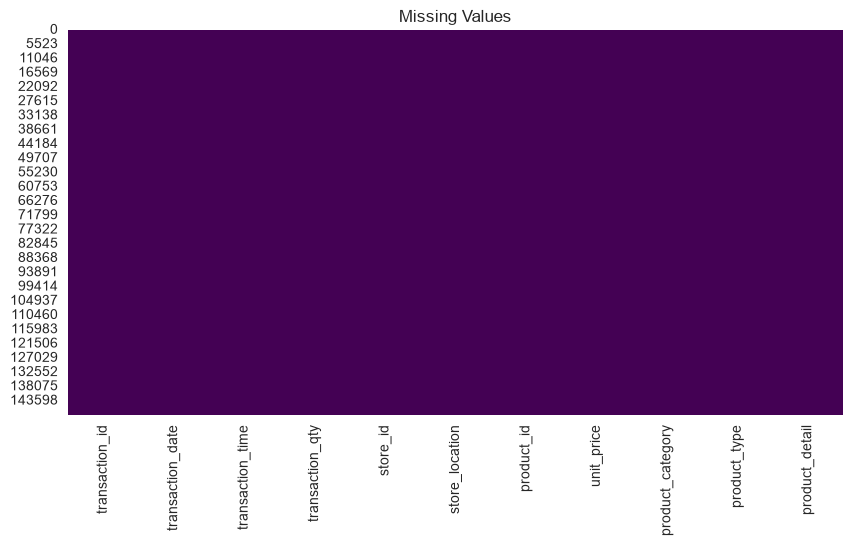

In [12]:
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap="viridis")

plt.title("Missing Values")
plt.show()

In [13]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [14]:
df.dtypes

transaction_id               int64
transaction_date    datetime64[ns]
transaction_time            object
transaction_qty              int64
store_id                     int64
store_location              object
product_id                   int64
unit_price                 float64
product_category            object
product_type                object
product_detail              object
dtype: object

In [15]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns

categorical_cols = df.select_dtypes(include='object').columns

print("Numerical Columns")
print(numerical_cols)

print("\nCategorical Columns")
print(categorical_cols)

Numerical Columns
Index(['transaction_id', 'transaction_qty', 'store_id', 'product_id',
       'unit_price'],
      dtype='object')

Categorical Columns
Index(['transaction_time', 'store_location', 'product_category',
       'product_type', 'product_detail'],
      dtype='object')


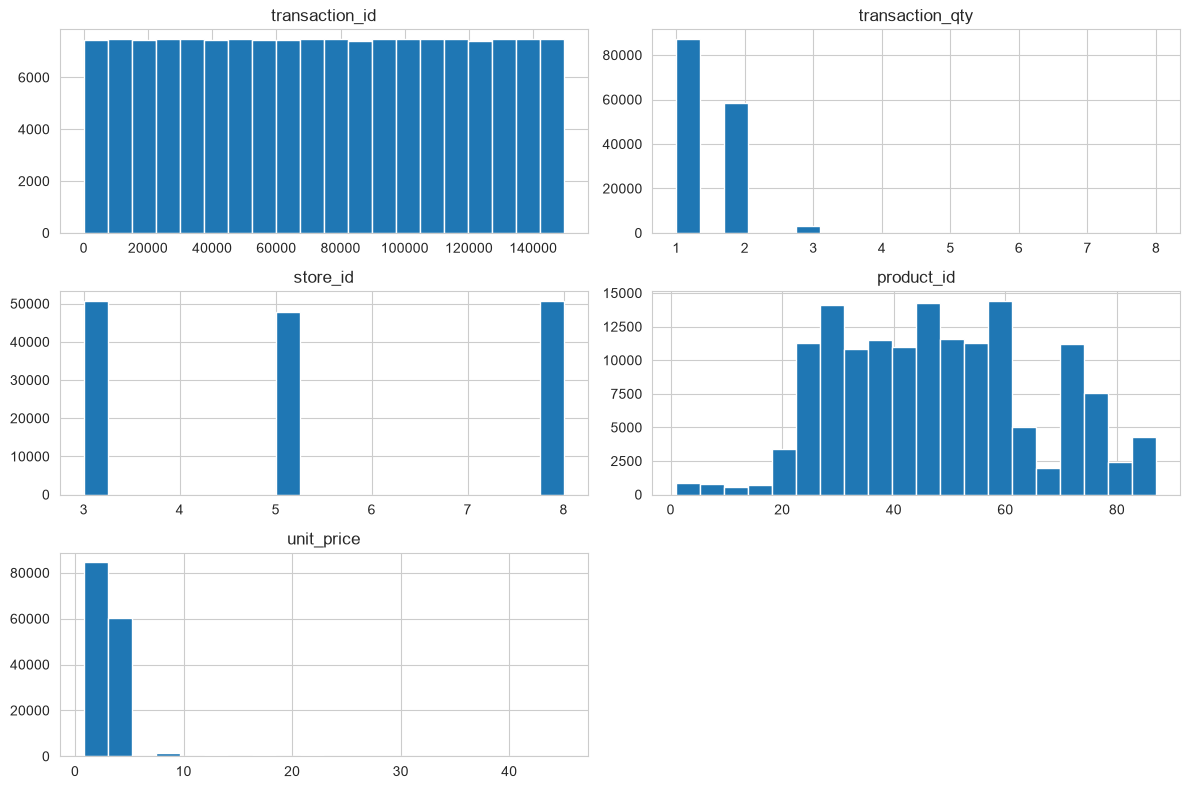

In [16]:
df[numerical_cols].hist(figsize=(12,8), bins=20)

plt.tight_layout()
plt.show()

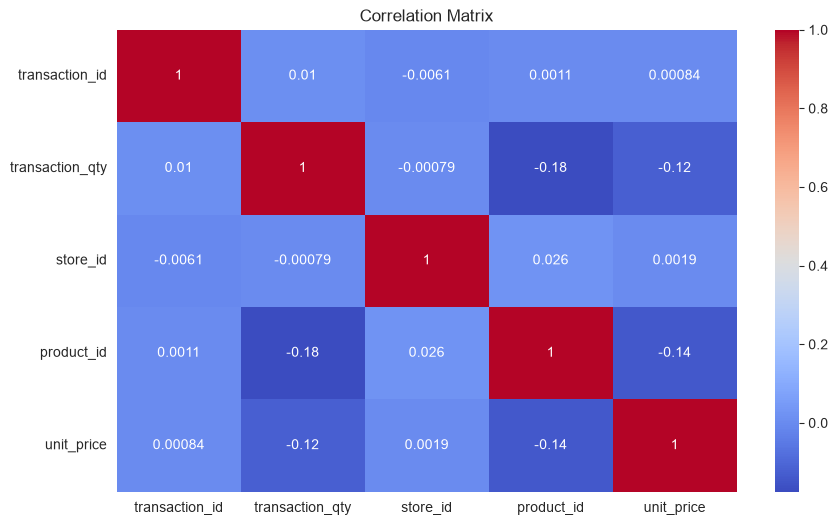

In [17]:
plt.figure(figsize=(10,6))

sns.heatmap(df[numerical_cols].corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

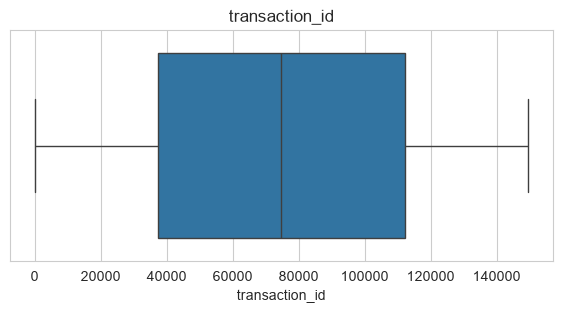

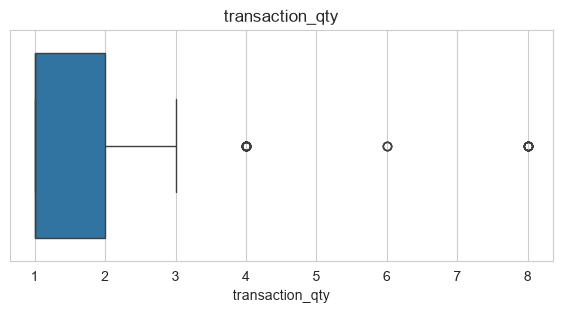

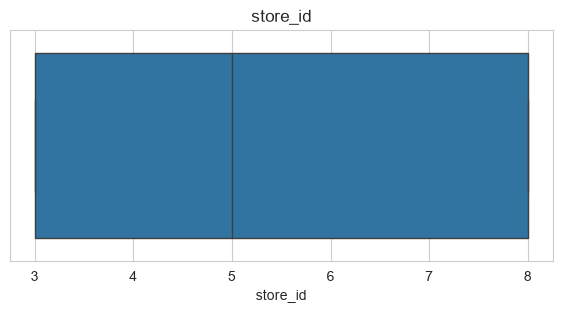

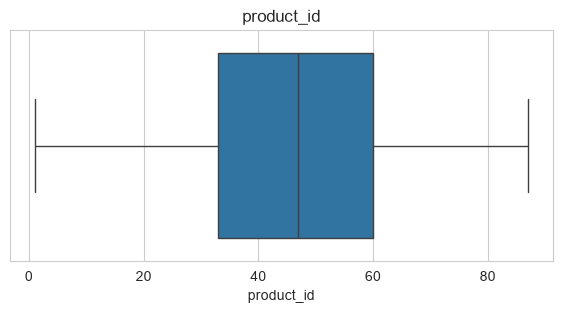

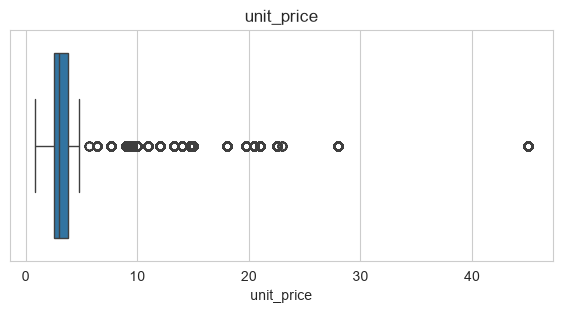

In [18]:
for column in numerical_cols:

    plt.figure(figsize=(7,3))

    sns.boxplot(x=df[column])

    plt.title(column)

    plt.show()

In [19]:
for column in categorical_cols:

    print("\n",column)

    print(df[column].value_counts())

    print("-"*50)


 transaction_time
transaction_time
09:31:15    41
08:15:41    40
08:19:08    38
10:34:04    36
11:40:03    36
            ..
18:09:15     1
17:58:36     1
17:37:16     1
17:25:48     1
17:23:01     1
Name: count, Length: 25762, dtype: int64
--------------------------------------------------

 store_location
store_location
Hell's Kitchen     50735
Astoria            50599
Lower Manhattan    47782
Name: count, dtype: int64
--------------------------------------------------

 product_category
product_category
Coffee                58416
Tea                   45449
Bakery                22796
Drinking Chocolate    11468
Flavours               6790
Coffee beans           1753
Loose Tea              1210
Branded                 747
Packaged Chocolate      487
Name: count, dtype: int64
--------------------------------------------------

 product_type
product_type
Brewed Chai tea          17183
Gourmet brewed coffee    16912
Barista Espresso         16403
Hot chocolate            11468
Brewed

Skipping 'transaction_time' (Too many unique values: 25762)


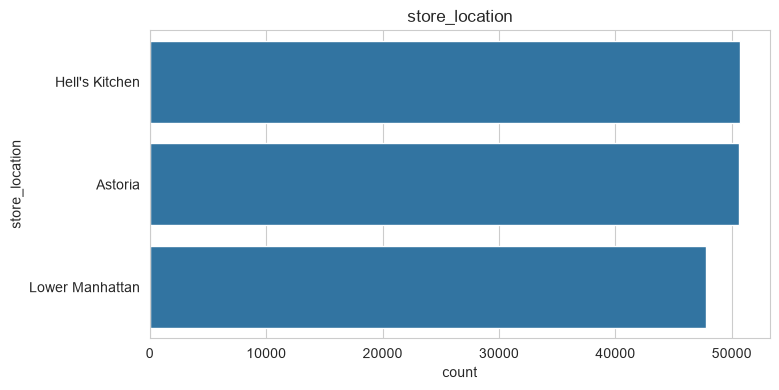

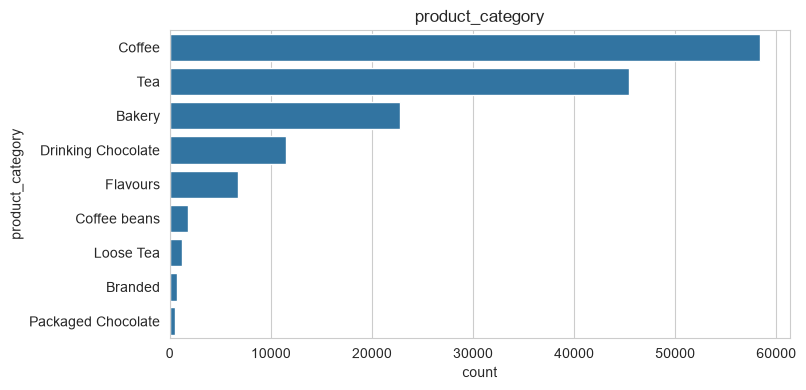

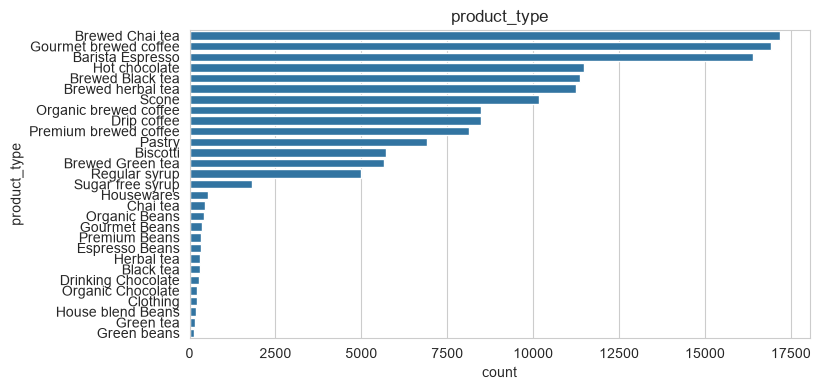

Skipping 'product_detail' (Too many unique values: 80)


In [22]:

max_categories = 50 

for column in categorical_cols:
   
    if df[column].nunique() <= max_categories:
        plt.figure(figsize=(8,4))
        sns.countplot(y=df[column], order=df[column].value_counts().index)
        plt.title(column)
        plt.show()
    else:
        print(f"Skipping '{column}' (Too many unique values: {df[column].nunique()})")

In [23]:

df['transaction_date'] = pd.to_datetime(df['transaction_date'])


df.dtypes

transaction_id               int64
transaction_date    datetime64[ns]
transaction_time            object
transaction_qty              int64
store_id                     int64
store_location              object
product_id                   int64
unit_price                 float64
product_category            object
product_type                object
product_detail              object
dtype: object

In [24]:
df['Month'] = df['transaction_date'].dt.month_name()

df['Day'] = df['transaction_date'].dt.day_name()

df['Year'] = df['transaction_date'].dt.year

In [44]:
monthly_sales = df.groupby('Month')['transaction_qty'].sum()

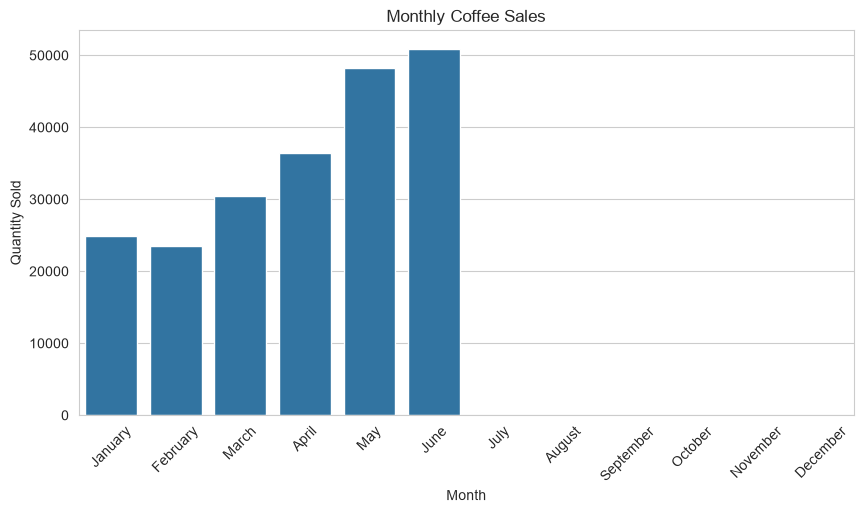

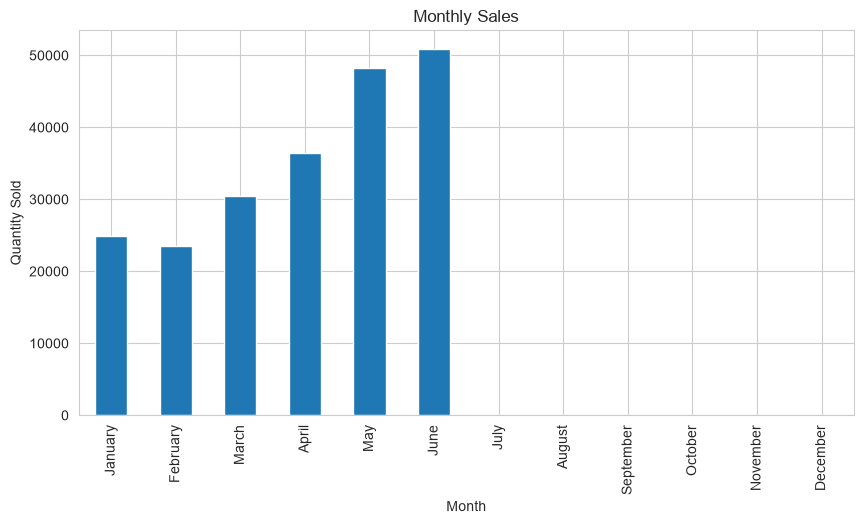

In [51]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_sales = (
    df.groupby('Month')['transaction_qty']
      .sum()
      .reindex(month_order)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=monthly_sales.index,
    y=monthly_sales.values
)

plt.title("Monthly Coffee Sales")
plt.xlabel("Month")
plt.ylabel("Quantity Sold")

plt.xticks(rotation=45)

plt.show()

monthly_sales.plot(kind='bar',
                   figsize=(10,5))

plt.title("Monthly Sales")

plt.ylabel("Quantity Sold")

plt.show()

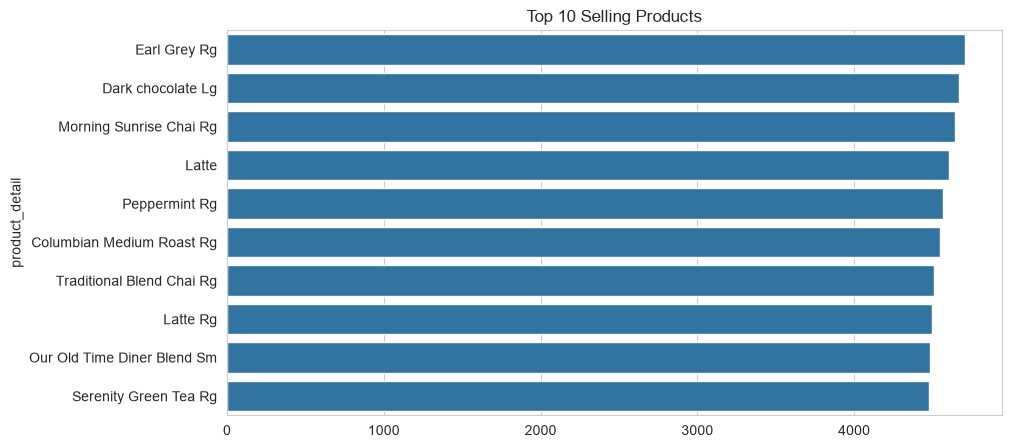

In [46]:
top_products = df.groupby('product_detail')['transaction_qty'].sum()

top_products = top_products.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

sns.barplot(x=top_products.values,
            y=top_products.index)

plt.title("Top 10 Selling Products")

plt.show()

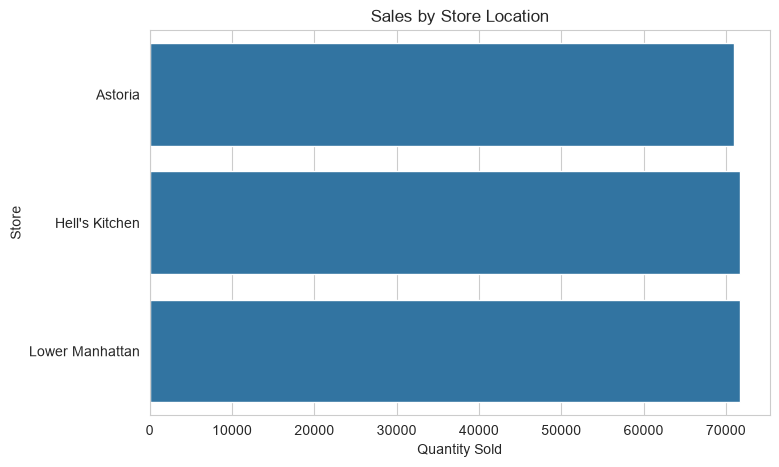

In [53]:
location_sales = df.groupby('store_location')['transaction_qty'].sum().sort_values()

plt.figure(figsize=(8,5))

sns.barplot(
    x=location_sales.values,
    y=location_sales.index
)

plt.title("Sales by Store Location")
plt.xlabel("Quantity Sold")
plt.ylabel("Store")

plt.show()

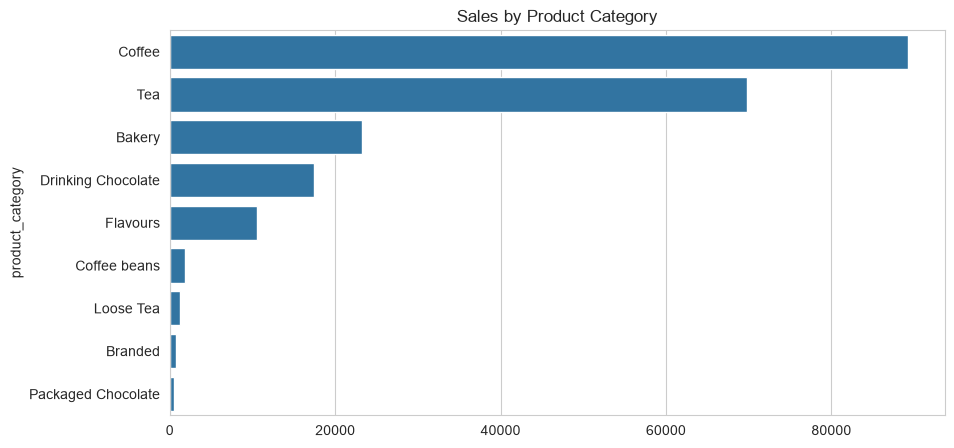

In [48]:
category_sales = df.groupby('product_category')['transaction_qty'].sum()

category_sales = category_sales.sort_values(ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(x=category_sales.values,
            y=category_sales.index)

plt.title("Sales by Product Category")

plt.show()

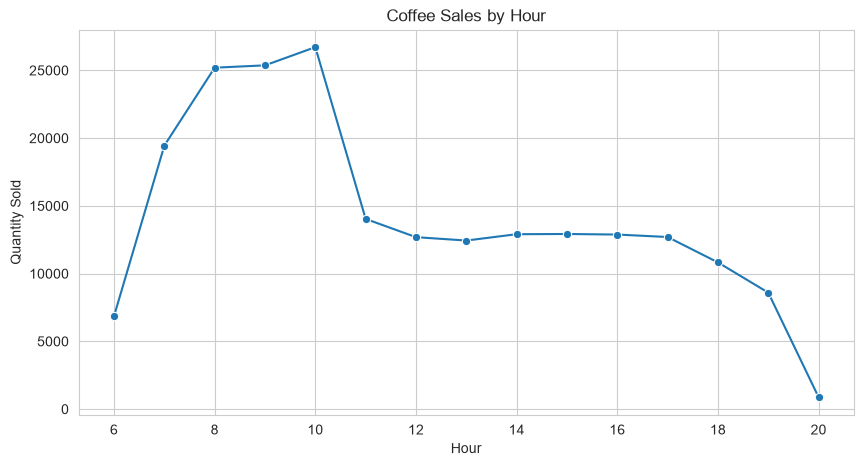

In [52]:
hourly_sales = df.groupby('transaction_hour')['transaction_qty'].sum()

plt.figure(figsize=(10,5))

sns.lineplot(
    x=hourly_sales.index,
    y=hourly_sales.values,
    marker='o'
)

plt.title("Coffee Sales by Hour")
plt.xlabel("Hour")
plt.ylabel("Quantity Sold")

plt.show()

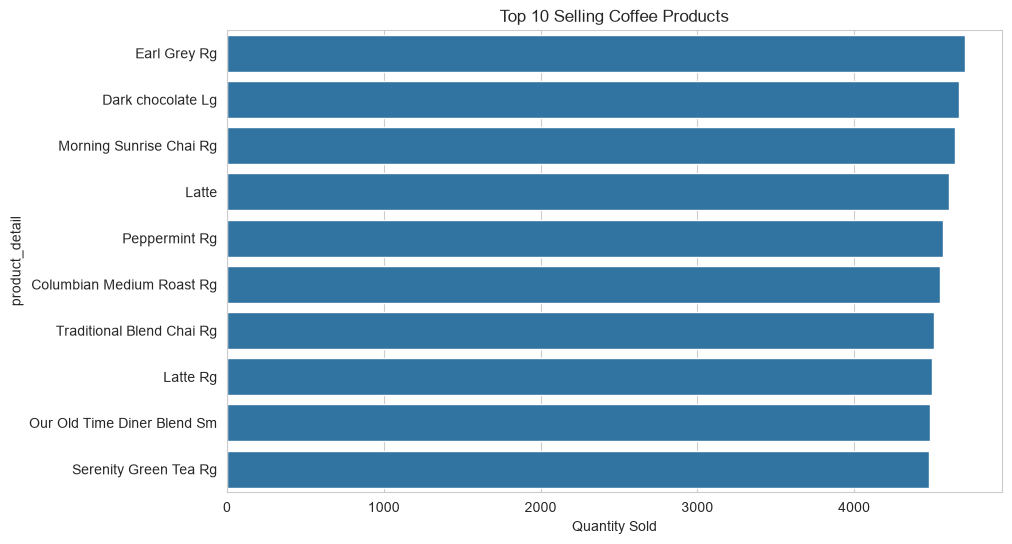

In [54]:
top_products = (
    df.groupby('product_detail')['transaction_qty']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Selling Coffee Products")
plt.xlabel("Quantity Sold")

plt.show()

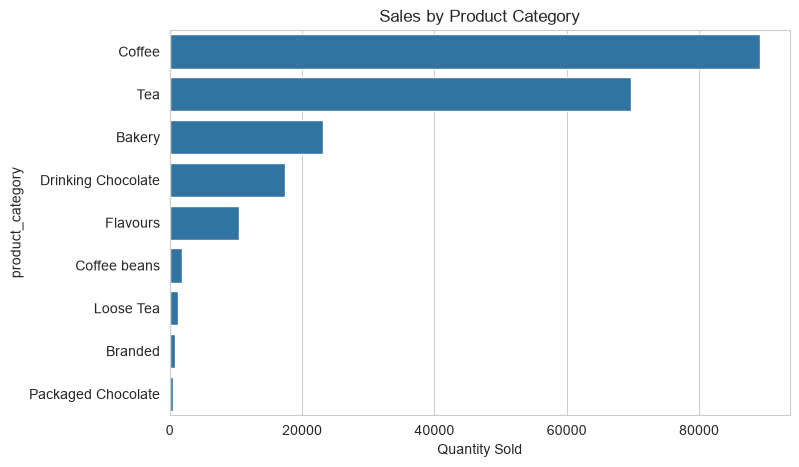

In [55]:
category_sales = (
    df.groupby('product_category')['transaction_qty']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.values,
    y=category_sales.index
)

plt.title("Sales by Product Category")
plt.xlabel("Quantity Sold")

plt.show()